In [1]:
# KNN Recommendation Model - Visualisasi Hasil
# Notebook ini memvisualisasikan hasil dari `train_model.py` dan `evaluate_model.py`.

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Libraries loaded!')

C:\Users\leona\AppData\Local\Temp\ipykernel_44396\3103221185.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Libraries loaded!


## 1. Load Data & Rebuild Item-Transaction Matrix

In [7]:
df = pd.read_csv('../data/bread_basket.csv')
df.columns = df.columns.str.strip()
df = df[df['Item'] != 'NONE']

chosen_items = [
    'Bread', 'Salad', 'Hot chocolate', 'Jam', 'Cookies', 'Muffin', 'Coffee', 'Pastry',
    'Medialuna', 'Tea', 'Tartine', 'Basket', 'Mineral water', 'Fudge', 'Juice',
    'Victorian Sponge', 'Frittata', 'Soup', 'Smoothies', 'Cake', 'Coke', 'Sandwich',
    'Baguette', 'Eggs', 'Brownie', 'Bread Pudding', 'Bacon', 'Toast', 'Scone', 'Crepes'
]
df = df[df['Item'].isin(chosen_items)]

item_transaction_matrix = pd.crosstab(df['Item'], df['Transaction']).clip(upper=1)

with open('../models/knn_recommendations.json', 'r') as f:
    rekomendasi_model = json.load(f)

print(f'Items: {item_transaction_matrix.shape[0]}')
print(f'Transactions: {item_transaction_matrix.shape[1]}')

Items: 30
Transactions: 8873


## 2. Distribusi Frekuensi Item

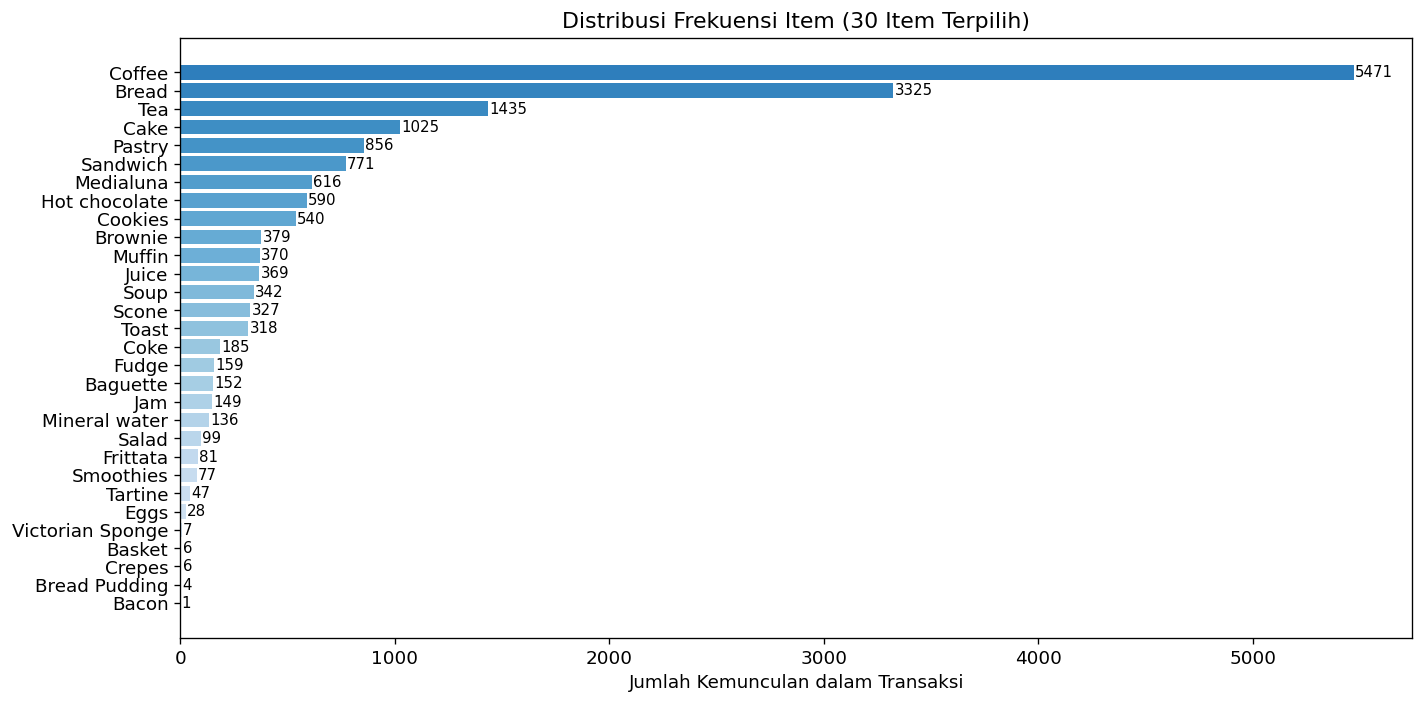

In [8]:
item_counts = df['Item'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(item_counts.index, item_counts.values,
               color=plt.cm.Blues_r(np.linspace(0.3, 0.9, len(item_counts))))

for bar, val in zip(bars, item_counts.values):
    ax.text(val + 5, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Jumlah Kemunculan dalam Transaksi')
ax.set_title('Distribusi Frekuensi Item (30 Item Terpilih)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Heatmap Cosine Similarity Antar Item

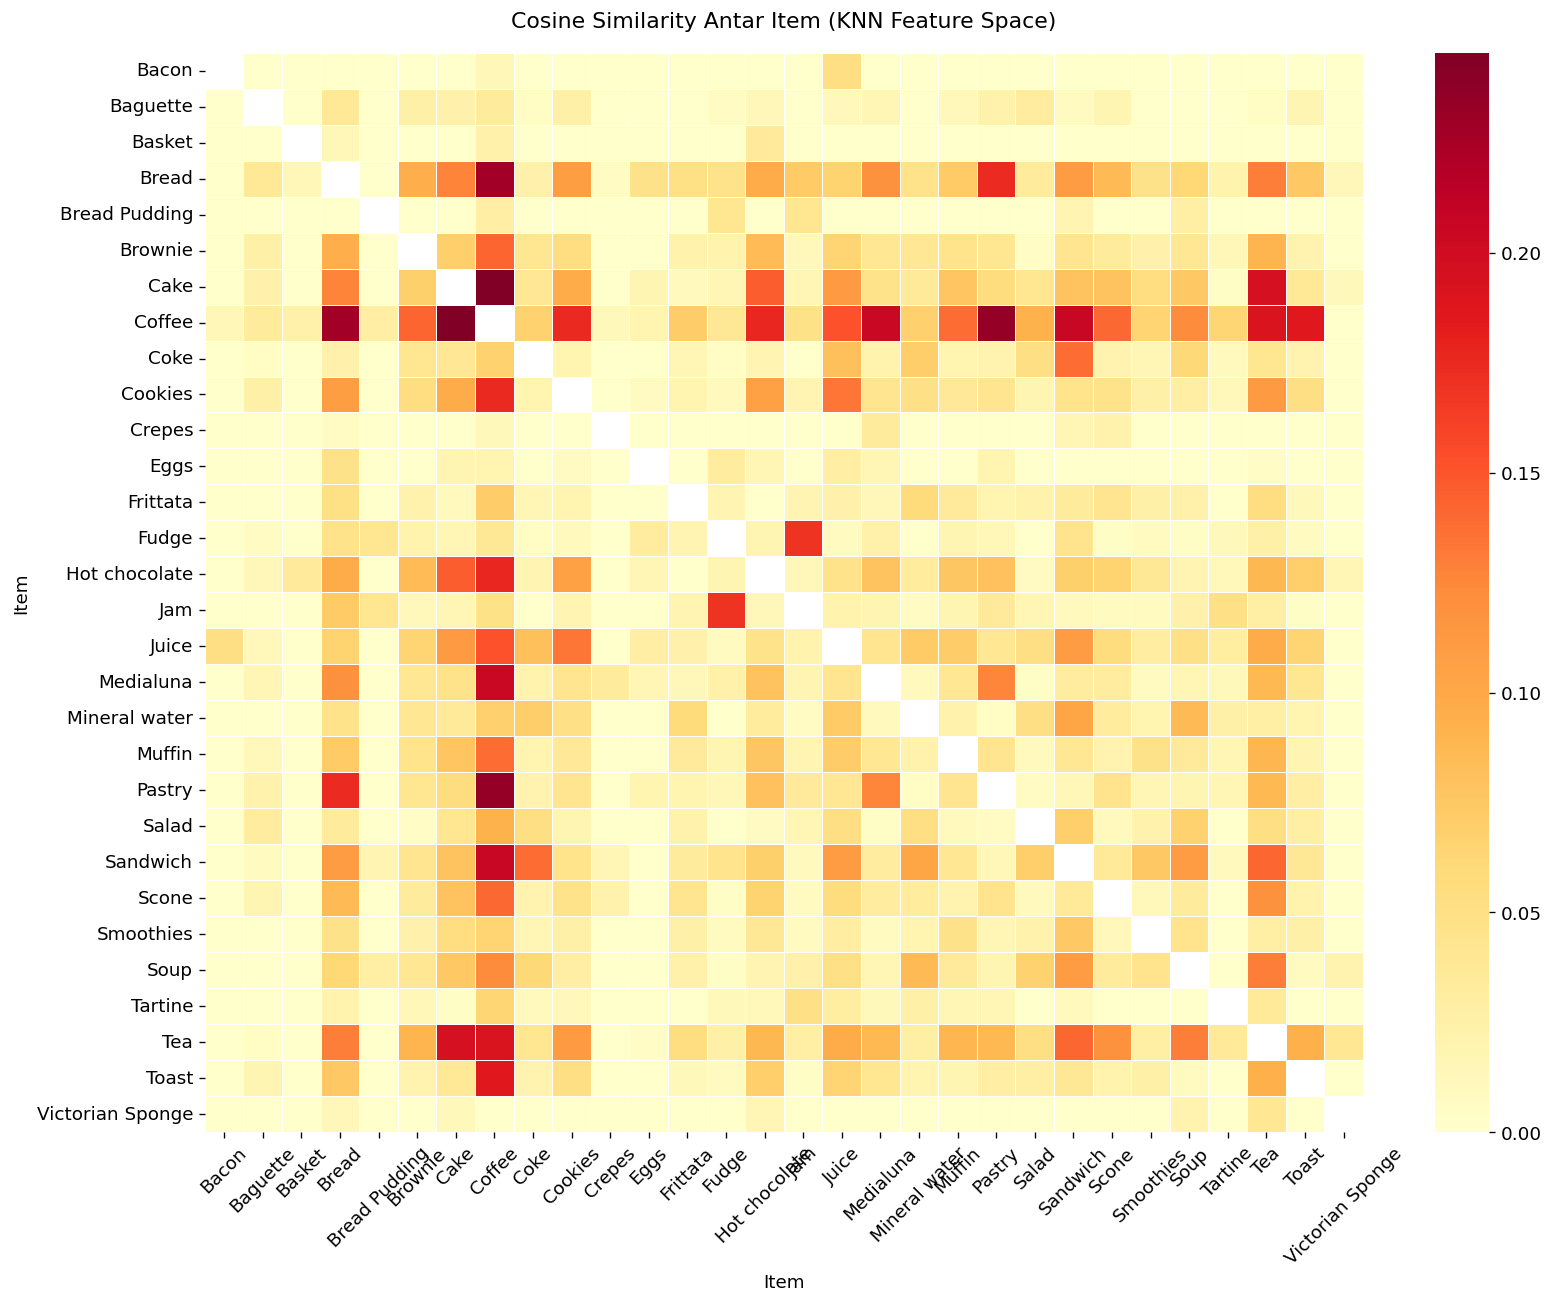

In [9]:
cos_sim = cosine_similarity(item_transaction_matrix.values)
cos_sim_df = pd.DataFrame(cos_sim,
                           index=item_transaction_matrix.index,
                           columns=item_transaction_matrix.index)

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.eye(len(cos_sim_df), dtype=bool)  # mask diagonal
sns.heatmap(cos_sim_df, mask=mask, annot=False, fmt='.2f',
            cmap='YlOrRd', linewidths=0.3, ax=ax,
            vmin=0, vmax=cos_sim_df.values[~mask].max())
ax.set_title('Cosine Similarity Antar Item (KNN Feature Space)', pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## 4. Top-5 Nearest Neighbor per Item

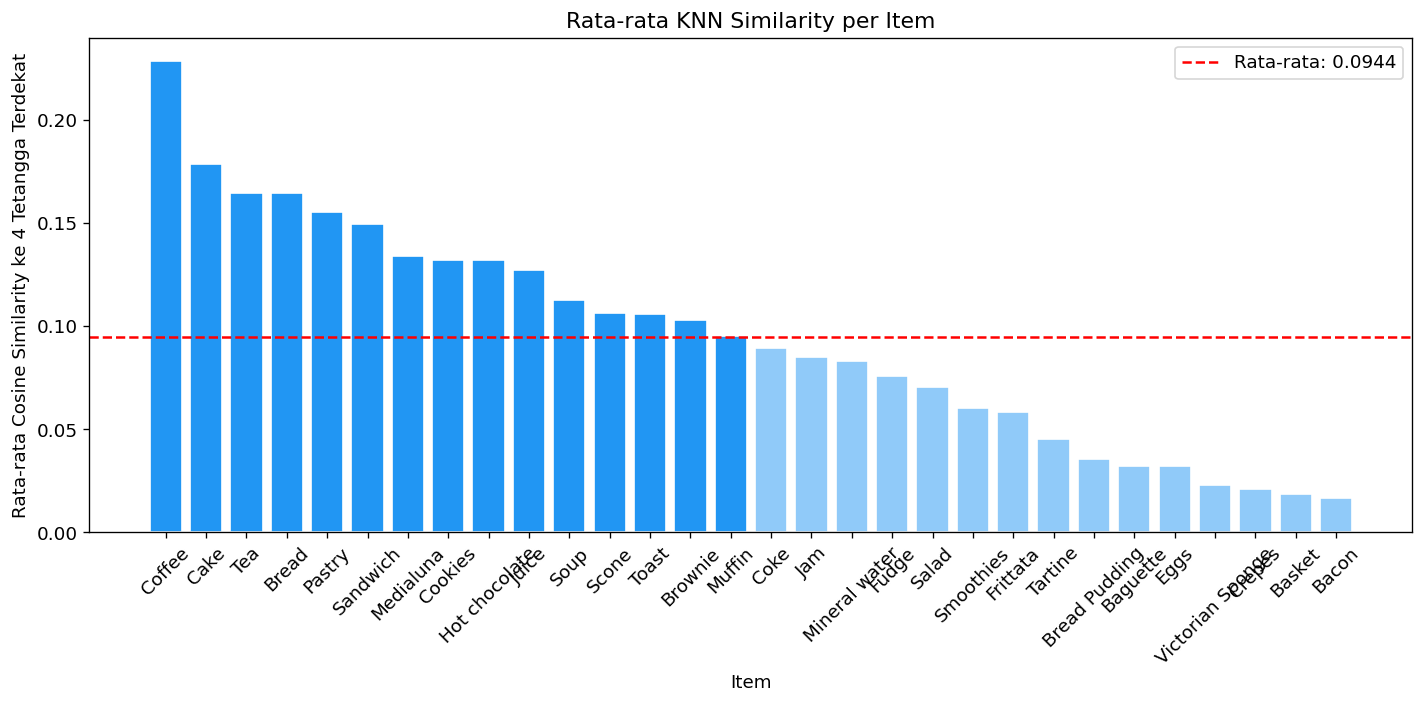

In [10]:
knn = NearestNeighbors(metric='cosine', algorithm='brute', n_neighbors=5)
knn.fit(item_transaction_matrix.values)

items = item_transaction_matrix.index.tolist()
distance_records = []
for i, item in enumerate(items):
    distances, indices = knn.kneighbors(
        item_transaction_matrix.iloc[i, :].values.reshape(1, -1)
    )
    for rank, (d, idx) in enumerate(zip(distances.flatten()[1:], indices.flatten()[1:]), 1):
        distance_records.append({
            'Source': item,
            'Neighbor': items[idx],
            'Rank': rank,
            'Distance': round(d, 4),
            'Similarity': round(1 - d, 4)
        })

dist_df = pd.DataFrame(distance_records)

# Plot: rata-rata similarity setiap item ke 4 tetangganya
avg_sim = dist_df.groupby('Source')['Similarity'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#2196F3' if s > avg_sim.mean() else '#90CAF9' for s in avg_sim.values]
bars = ax.bar(avg_sim.index, avg_sim.values, color=colors, edgecolor='white')
ax.axhline(avg_sim.mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Rata-rata: {avg_sim.mean():.4f}')
ax.set_xlabel('Item')
ax.set_ylabel('Rata-rata Cosine Similarity ke 4 Tetangga Terdekat')
ax.set_title('Rata-rata KNN Similarity per Item')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Jaringan Rekomendasi KNN (Network Graph)

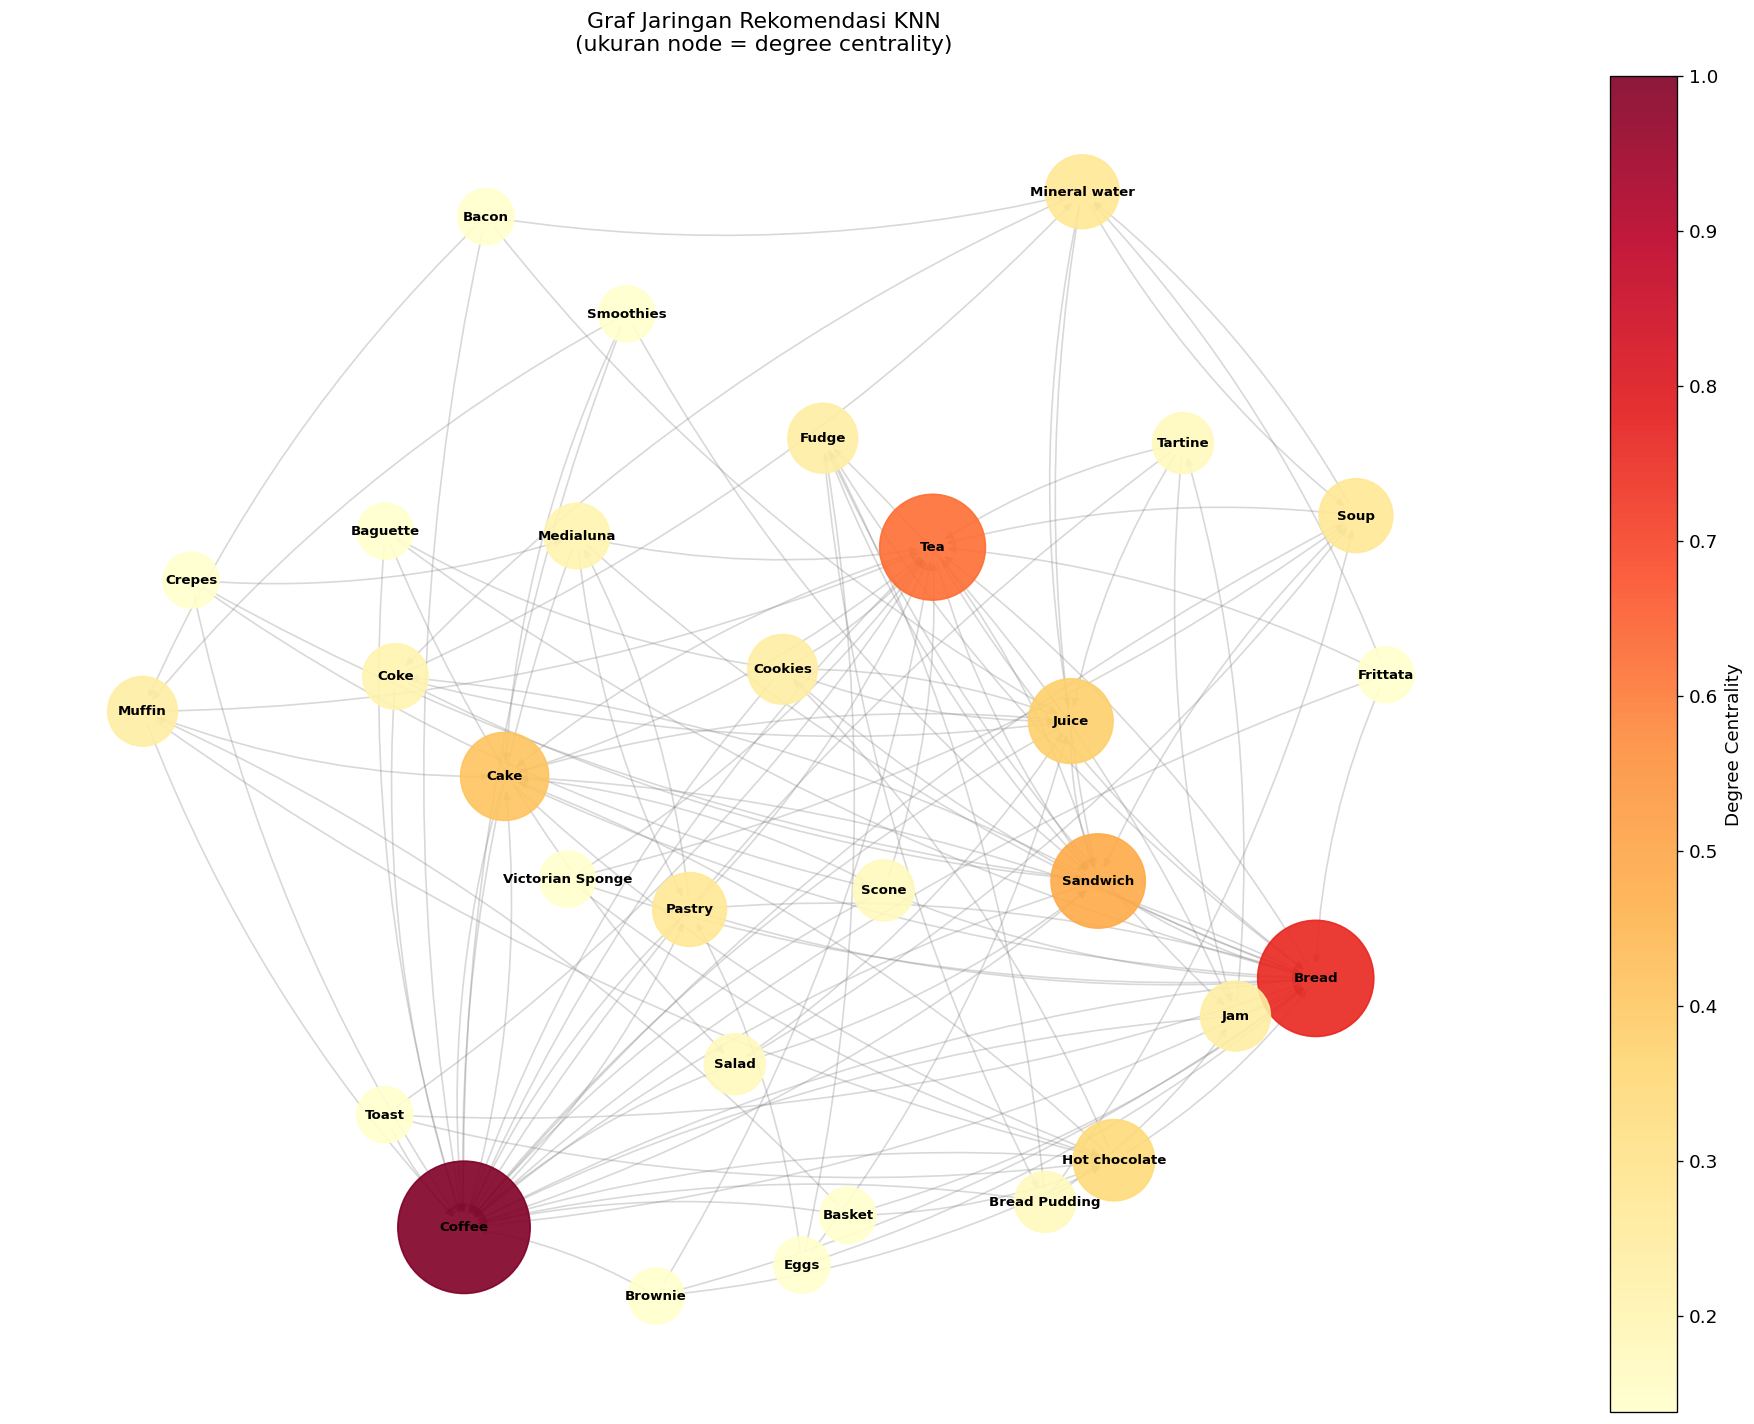

In [11]:
G = nx.DiGraph()
for source, neighbors in rekomendasi_model.items():
    for neighbor in neighbors:
        G.add_edge(source, neighbor)

degree_centrality = nx.degree_centrality(G)
node_sizes = [degree_centrality[n] * 6000 + 300 for n in G.nodes()]
node_colors = [degree_centrality[n] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(G, seed=42, k=1.5)

nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                                node_color=node_colors, cmap=plt.cm.YlOrRd,
                                ax=ax, alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, arrows=True,
                       arrowsize=10, edge_color='gray',
                       connectionstyle='arc3,rad=0.1')
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight='bold')

plt.colorbar(nodes, ax=ax, label='Degree Centrality')
ax.set_title('Graf Jaringan Rekomendasi KNN\n(ukuran node = degree centrality)', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Evaluasi Model: Hit Ratio, Precision, Recall@4

Hit Ratio@4 : 77.06%
Precision@4 : 19.35%
Recall@4    : 77.06%
Total evaluasi: 4781 transaksi


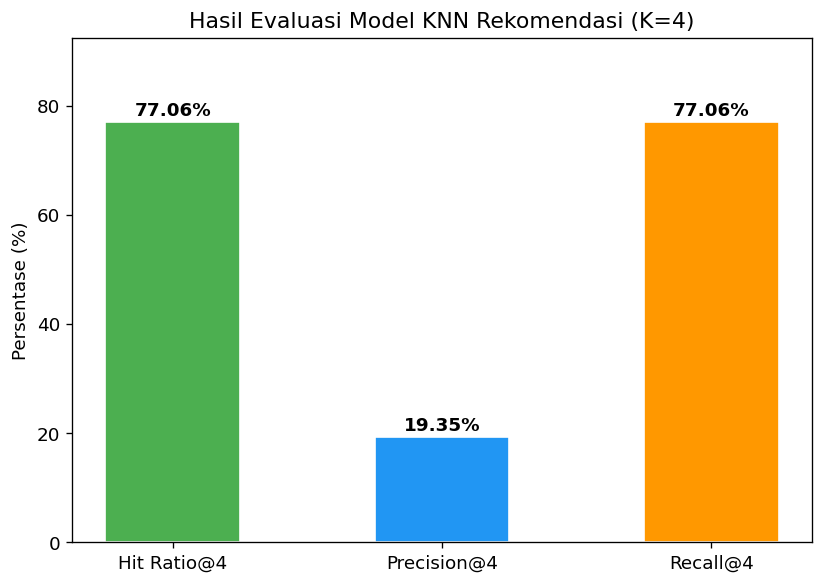

In [12]:
transaksi_dict = df.groupby('Transaction')['Item'].apply(lambda x: list(set(x))).to_dict()
transaksi_valid = {k: v for k, v in transaksi_dict.items() if len(v) >= 2}

hits = 0
total_precision = 0
total_recall = 0
total_eval = 0
K = 4

per_item_hit = {item: {'hit': 0, 'total': 0} for item in chosen_items}

for tx_id, items in transaksi_valid.items():
    target_item = items[-1]
    input_items = items[:-1]

    hasil_prediksi = []
    for item in input_items:
        if item in rekomendasi_model:
            hasil_prediksi.extend(rekomendasi_model[item])

    prediksi_unik = []
    for p in hasil_prediksi:
        if p not in prediksi_unik and p not in input_items:
            prediksi_unik.append(p)

    top_k_prediksi = prediksi_unik[:K]

    if not top_k_prediksi:
        continue

    total_eval += 1
    benar = 1 if target_item in top_k_prediksi else 0

    if target_item in chosen_items:
        per_item_hit[target_item]['total'] += 1
        per_item_hit[target_item]['hit'] += benar

    hits += benar
    total_precision += benar / len(top_k_prediksi)
    total_recall += benar / 1

hit_ratio  = (hits / total_eval) * 100
precision  = (total_precision / total_eval) * 100
recall     = (total_recall / total_eval) * 100

print(f'Hit Ratio@{K} : {hit_ratio:.2f}%')
print(f'Precision@{K} : {precision:.2f}%')
print(f'Recall@{K}    : {recall:.2f}%')
print(f'Total evaluasi: {total_eval} transaksi')

# --- Plot metrik utama ---
metrics = {'Hit Ratio@4': hit_ratio, 'Precision@4': precision, 'Recall@4': recall}
colors  = ['#4CAF50', '#2196F3', '#FF9800']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(metrics.keys(), metrics.values(), color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

ax.set_ylim(0, max(metrics.values()) * 1.2)
ax.set_ylabel('Persentase (%)')
ax.set_title(f'Hasil Evaluasi Model KNN Rekomendasi (K={K})')
plt.tight_layout()
plt.show()

## 7. Hit Rate per Item

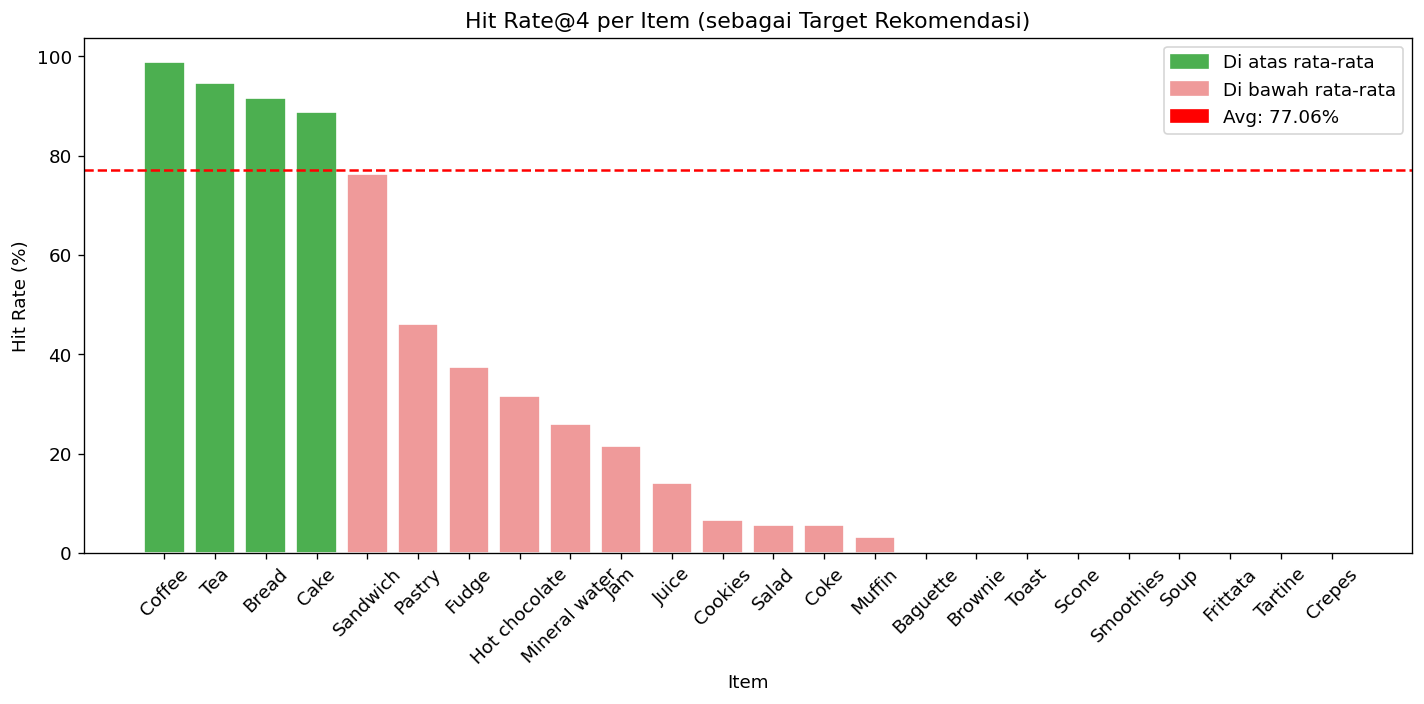

In [13]:
item_hit_rates = {
    item: (v['hit'] / v['total'] * 100) if v['total'] > 0 else 0
    for item, v in per_item_hit.items()
}
item_hit_series = pd.Series(item_hit_rates).sort_values(ascending=False)
item_total_series = pd.Series({item: v['total'] for item, v in per_item_hit.items()})

# Hanya tampilkan item yang punya minimal 1 evaluasi
item_hit_series = item_hit_series[item_total_series > 0]

fig, ax = plt.subplots(figsize=(12, 6))
palette = ['#4CAF50' if v >= hit_ratio else '#EF9A9A' for v in item_hit_series.values]
bars = ax.bar(item_hit_series.index, item_hit_series.values, color=palette, edgecolor='white')
ax.axhline(hit_ratio, color='red', linestyle='--', linewidth=1.5,
           label=f'Avg Hit Ratio: {hit_ratio:.2f}%')

green_patch = mpatches.Patch(color='#4CAF50', label='Di atas rata-rata')
red_patch   = mpatches.Patch(color='#EF9A9A', label='Di bawah rata-rata')
ax.legend(handles=[green_patch, red_patch,
          mpatches.Patch(color='red', label=f'Avg: {hit_ratio:.2f}%')])

ax.set_xlabel('Item')
ax.set_ylabel('Hit Rate (%)')
ax.set_title('Hit Rate@4 per Item (sebagai Target Rekomendasi)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()